# Cluster Deep Dive

Semantic coherence, soft-membership probabilities, UMAP-seed stability (ARI), cluster cards (TF-IDF keywords + samples), language diversity (Shannon entropy), and pairwise centroid similarity.


In [2]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, silhouette_score
import scipy.stats as stats
import umap
import hdbscan

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

_nb_file = globals().get('__vsc_ipynb_file__', None)
if _nb_file:
    REPO_ROOT = Path(_nb_file).parent.parent
else:
    _cwd = Path.cwd()
    REPO_ROOT = _cwd if (_cwd / 'gcp_config.py').exists() else _cwd.parent

NB_DIR   = REPO_ROOT / 'notebooks'
DATA_DIR = REPO_ROOT / 'data'
FIGURES_DIR = DATA_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = DATA_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
PLOT_DIR = DATA_DIR

sys.path.insert(0, str(REPO_ROOT))
from gcp_config import PROJECT_ID, bq_table
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

TRACK = 'multilingual'
lbl   = 'Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d)'
TEXT_COL = 'chunk_text'
LANG_COL = 'detected_language'

df = client.query(f"""
    SELECT
        cl.chunk_uid,
        cl.conversation_id,
        cl.cluster_id,
        cl.is_noise,
        cl.hdbscan_prob       AS membership_prob,
        cl.detected_language,
        cl.umap_x,
        cl.umap_y,
        cl.original_chunk_text AS chunk_text
    FROM `{bq_table('chunk_cluster_labels')}` cl
    ORDER BY cl.chunk_uid
""").to_dataframe()

emb_file = None
for p in (DATA_DIR / 'chunk_embeddings_finetuned.npy', DATA_DIR / 'chunk_embeddings_multilingual.npy'):
    if p.exists():
        emb_file = p
        break

if emb_file is not None:
    embeddings = np.load(emb_file)
    if len(embeddings) != len(df):
        raise ValueError(
            f'Embedding rows {len(embeddings)} != BQ chunk rows {len(df)}; refresh {emb_file.name} or chunk_cluster_labels.'
        )
else:
    embeddings = None

umap_2d = df[['umap_x', 'umap_y']].values if 'umap_x' in df.columns else None

cluster_ids = sorted(df[df.cluster_id >= 0].cluster_id.unique())

td = {
    'df': df, 'embeddings': embeddings, 'umap_15d': umap_2d,
    'cluster_ids': cluster_ids, 'label': lbl
}

n_noise = int((df['cluster_id'] == -1).sum())
print(f'{lbl}: {len(df):,} chunks | {len(cluster_ids)} clusters | noise={n_noise} ({100 * n_noise / len(df):.1f}%)')
print(f'Embeddings: {embeddings.shape if embeddings is not None else "MISSING"}'
      f'{" (" + emb_file.name + ")" if emb_file is not None else " — run chunk_clustering.py"}')


Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d): 169,709 chunks | 24 clusters | noise=20346 (12.0%)
Embeddings: (169709, 384) (chunk_embeddings_finetuned.npy)



Semantic coherence (avg intra-cluster cosine):
 cluster_id     n  avg_cosine  min_cosine  std_cosine
          3  4115      0.9850      0.8048      0.0233
          1  5388      0.9787      0.6765      0.0383
          9  4491      0.9729      0.7544      0.0320
          4  4686      0.9717      0.7753      0.0421
         22  6261      0.9693      0.7146      0.0327
          6  5213      0.9663      0.6967      0.0401
         19  3567      0.9652      0.8199      0.0326
         12  7434      0.9617      0.7339      0.0435
         23  3143      0.9603      0.7486      0.0332
          7  5011      0.9596      0.6313      0.0447
         10  4948      0.9574      0.6366      0.0602
          0  3956      0.9565      0.7192      0.0555
         13  7998      0.9561      0.7539      0.0420
         14  6573      0.9557      0.6853      0.0487
         21  6068      0.9546      0.7252      0.0473
         15  7900      0.9515      0.6321      0.0574
         18  7152      0.9497     

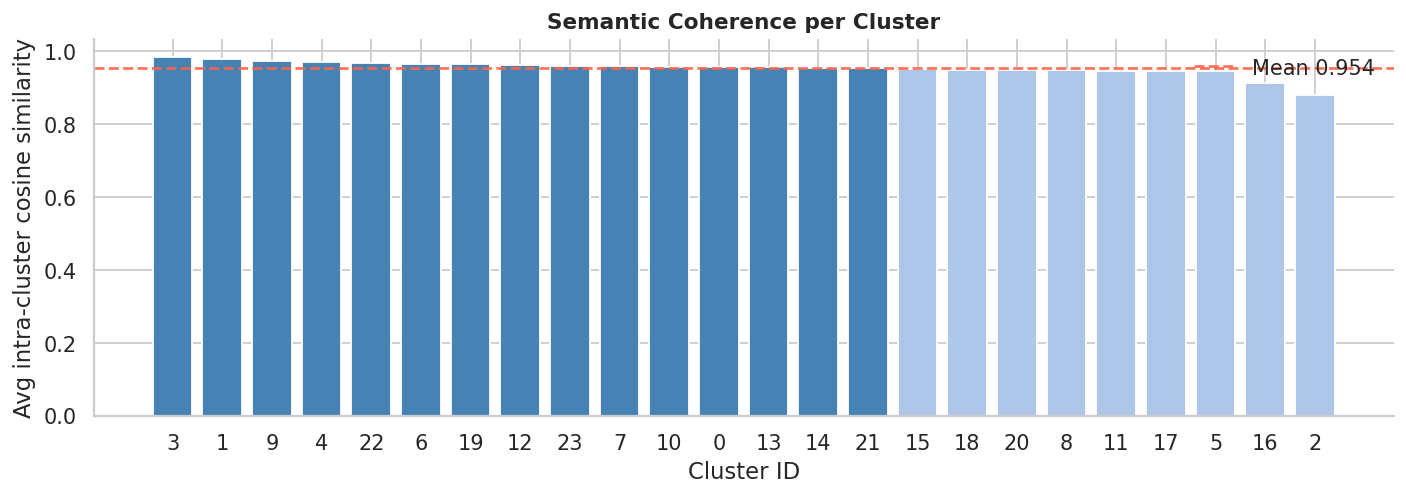

Mean intra-cluster cosine: 0.9542 +/- 0.0212


In [3]:
if embeddings is None:
    raise RuntimeError(f'{lbl}: embeddings missing — run chunk_clustering.py first')

coherence_rows = []
for cid in cluster_ids:
    idx  = df.index[df['cluster_id'] == cid].tolist()
    embs = embeddings[idx]
    if len(embs) < 2:
        coherence_rows.append({'cluster_id': cid, 'n': 1, 'avg_cosine': np.nan, 'min_cosine': np.nan})
        continue
    if len(embs) > 200:
        rng = np.random.default_rng(42)
        embs = embs[rng.choice(len(embs), 200, replace=False)]
    sim_matrix = cosine_similarity(embs)
    triu_idx = np.triu_indices(len(embs), k=1)
    sims = sim_matrix[triu_idx]
    coherence_rows.append({'cluster_id': cid, 'n': len(df[df['cluster_id'] == cid]),
                            'avg_cosine': round(sims.mean(), 4), 'min_cosine': round(sims.min(), 4),
                            'std_cosine': round(sims.std(), 4)})

coh_df = pd.DataFrame(coherence_rows).sort_values('avg_cosine', ascending=False)
td['coh_df'] = coh_df
print(f'\nSemantic coherence (avg intra-cluster cosine):')
print(coh_df.to_string(index=False))

mean_coh = coh_df['avg_cosine'].mean()
fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = ['steelblue' if v >= mean_coh else '#aec7e8'
              for v in coh_df['avg_cosine']]
ax.bar(coh_df['cluster_id'].astype(str), coh_df['avg_cosine'], color=bar_colors)
ax.axhline(mean_coh, ls='--', color='tomato', lw=1.5, alpha=0.9, label=f'Mean {mean_coh:.3f}')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Avg intra-cluster cosine similarity')
ax.set_title('Semantic Coherence per Cluster', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'cluster_coherence_{TRACK}.png', dpi=130)
plt.show()
coh_df.to_csv(RESULTS_DIR / f'cluster_coherence_{TRACK}.csv', index=False)
print(f'Mean intra-cluster cosine: {mean_coh:.4f} +/- {coh_df["avg_cosine"].std():.4f}')



Re-fitting HDBSCAN with soft clustering ...
Borderline points (prob < 0.2): 0.7% of clustered chunks


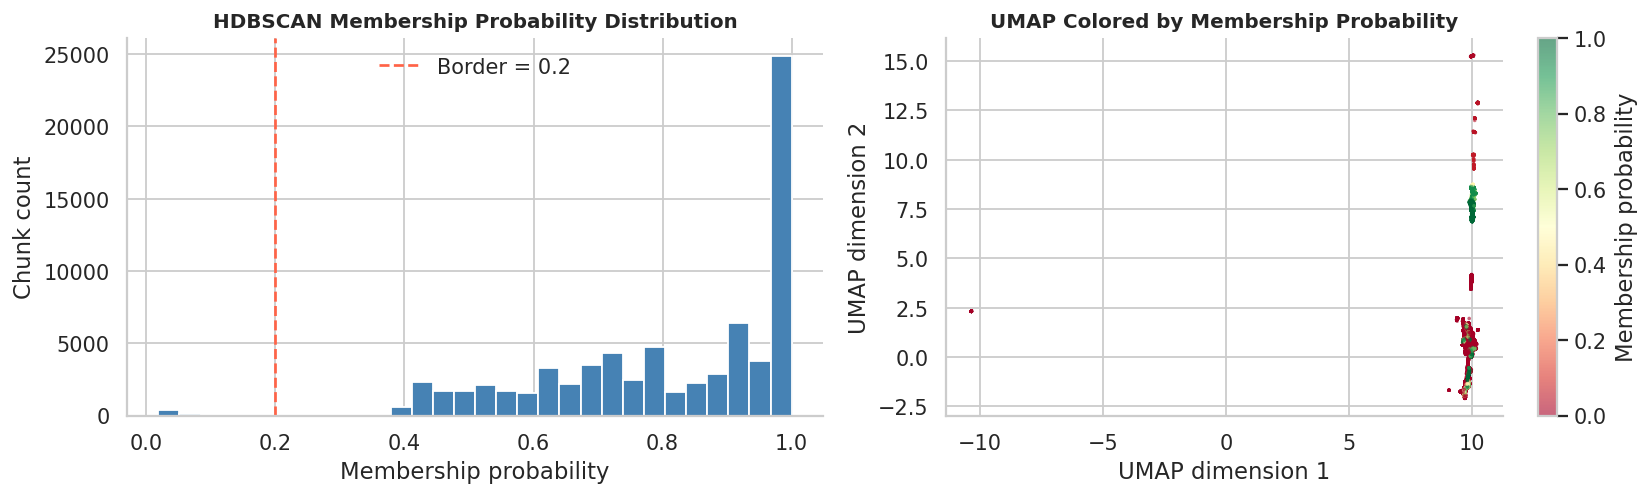

In [4]:
HDBSCAN_MIN_CLUSTER_SIZE = 2000
HDBSCAN_MIN_SAMPLES      = 20
HDBSCAN_METRIC           = 'euclidean'
import hdbscan as hdb_lib

umap_15d = td['umap_15d']

if umap_15d is None:
    raise RuntimeError(f'{lbl}: UMAP-15D missing — ensure umap_x/umap_y columns exist in chunk_cluster_labels')

print(f'\nRe-fitting HDBSCAN with soft clustering ...')
clusterer = hdb_lib.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method='leaf',
    prediction_data=True,
    core_dist_n_jobs=-1,
)
clusterer.fit(umap_15d)

probs = clusterer.probabilities_
df['hdbscan_prob'] = probs
td['probs'] = probs

BORDER_THRESH = 0.2
border_pct = (probs[probs > 0] < BORDER_THRESH).mean() * 100
print(f'Borderline points (prob < {BORDER_THRESH}): {border_pct:.1f}% of clustered chunks')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(probs[probs > 0], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(BORDER_THRESH, color='tomato', ls='--', lw=1.5, label=f'Border = {BORDER_THRESH}')
axes[0].set_title('HDBSCAN Membership Probability Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Membership probability')
axes[0].set_ylabel('Chunk count')
axes[0].legend(frameon=False)
sns.despine(ax=axes[0])

sc = axes[1].scatter(df['umap_x'], df['umap_y'], c=probs, cmap='RdYlGn',
                     s=4, alpha=0.6, vmin=0, vmax=1, linewidths=0)
plt.colorbar(sc, ax=axes[1], label='Membership probability')
axes[1].set_title('UMAP Colored by Membership Probability', fontsize=11, fontweight='bold')
axes[1].set_xlabel('UMAP dimension 1')
axes[1].set_ylabel('UMAP dimension 2')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'hdbscan_soft_probs_{TRACK}.png', dpi=130)
plt.show()


In [11]:
df, cluster_ids = td['df'], td['cluster_ids']
coh_df = td.get('coh_df')

tfidf = TfidfVectorizer(max_features=1000, stop_words='english',
                         ngram_range=(1, 2), max_df=0.9, min_df=2)
tfidf.fit(df[TEXT_COL].fillna('').tolist())
vocab = np.array(tfidf.get_feature_names_out())

print(f'\nCLUSTER CARDS — {lbl}')

card_rows = []
for cid in cluster_ids:
    mask_c        = df['cluster_id'] == cid
    cluster_texts = df[mask_c][TEXT_COL].dropna()

    X = tfidf.transform(cluster_texts.tolist())
    scores  = X.toarray().mean(axis=0)
    top_idx = scores.argsort()[::-1][:10]
    top_kw  = vocab[top_idx].tolist()

    samples = cluster_texts.sample(min(3, len(cluster_texts)), random_state=42).tolist()

    coh    = coh_df.loc[coh_df['cluster_id'] == cid, 'avg_cosine'].values if coh_df is not None else []
    coh_val = coh[0] if len(coh) else np.nan

    lang_dist = df[mask_c][LANG_COL].value_counts(normalize=True).head(3).to_dict() if LANG_COL in df.columns else {}

    card_rows.append({
        'cluster_id'    : cid,
        'n'             : mask_c.sum(),
        'top_keywords'  : ', '.join(top_kw),
        'avg_cosine'    : coh_val,
        'top_languages' : str(lang_dist),
    })

    print(f'\n--- Cluster {cid}  (n={mask_c.sum()}, coherence={coh_val:.3f}) ---')
    print(f'Keywords: {top_kw}')
    for i, s in enumerate(samples, 1):
        print(f'  [{i}] {s[:500]}')

cards_df = pd.DataFrame(card_rows)
cards_df.to_csv(RESULTS_DIR / f'cluster_cards_{TRACK}.csv', index=False)
print(f'\nSaved: cluster_cards_{TRACK}.csv')


CLUSTER CARDS — Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d)

--- Cluster 0  (n=3956, coherence=0.956) ---
Keywords: ['form', 'email', 'smtp', 'plugin', 'user', 'url', 'test', 'emails', 'settings', 'person']
  [1] [AI]: Salut, Andrei! 😊 Iată pașii pentru a crea un formular pe site-ul tău folosind 10Web AI Builder, astfel încât utilizatorii să poată descărca un ebook și să-l primească pe email:  

### Instrucțiuni:  

1. "Adaugă formularul":  
   - Din pagina "AI Builder" din Dashboard-ul 10Web, creează un formular nou.  
   - Adaugă câmpurile necesare, cum ar fi nume, email și alte informații relevante.
[AI]: 2. "Configurează acțiunile după trimitere":  
   - În secțiunea "Actions After Submit", asigură-t
  [2] [USER]: Hi. I have installed the FAQ plugin but am unable to find the shortcode. You site says there should be a tab where i can find it but there is nothing there?
[AI]: It seems you are looking for the shortcode for the FAQ plugin. Ba

Language diversity per cluster (Shannon entropy, bits):
 cluster_id     n top_lang  top_lang_pct  n_languages  entropy_bits
         22  6261       ar          12.5           64         4.450
         23  3143       es          15.5           52         4.265
         17  4867       es          22.5           40         3.933
          0  3956       en          87.3           29         1.037
          5  4021       en          93.7           20         0.554
         12  7434       en          96.2           27         0.386
          6  5213       en          97.5           34         0.277
          8 10499       en          97.5           35         0.273
          9  4491       en          97.6           19         0.250
          1  5388       en          97.9           27         0.232
          2  7926       en          98.0           32         0.229
          3  4115       en          97.9           21         0.225
         15  7900       en          98.3           30       

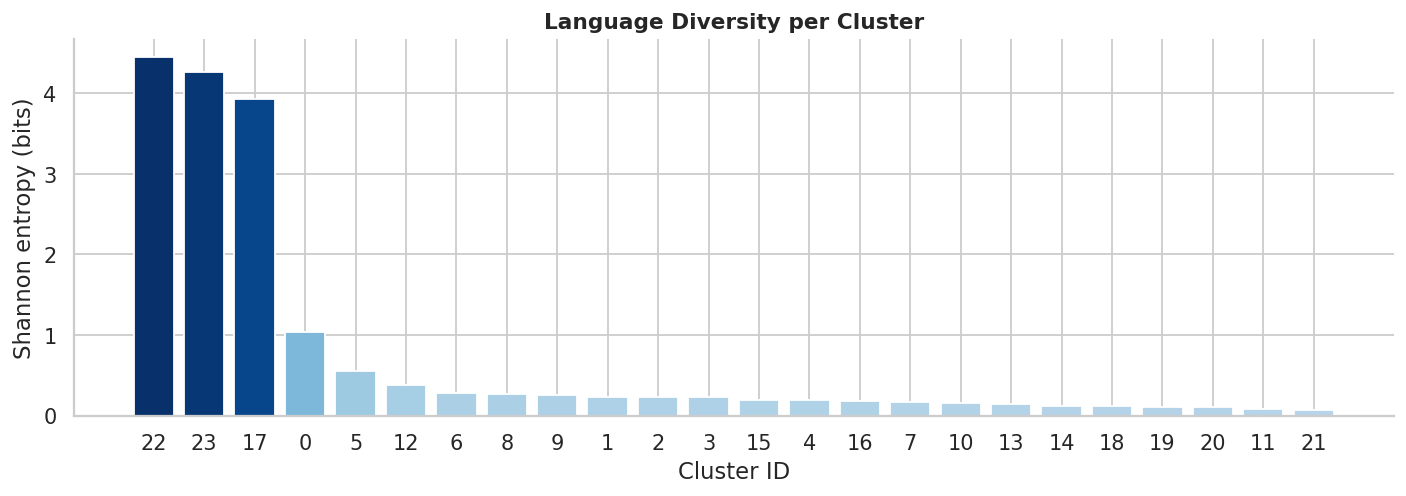

Saved: language_entropy.png + language_entropy.csv


In [12]:
if LANG_COL in df.columns:
    ent_rows = []
    for cid in cluster_ids:
        mask_c = df['cluster_id'] == cid
        lang_counts = df[mask_c][LANG_COL].dropna().value_counts(normalize=True)
        ent = stats.entropy(lang_counts.values, base=2)
        ent_rows.append({'cluster_id': cid, 'n': mask_c.sum(),
                          'top_lang': lang_counts.index[0] if len(lang_counts) > 0 else 'unk',
                          'top_lang_pct': round(lang_counts.iloc[0]*100, 1) if len(lang_counts) > 0 else 0,
                          'n_languages': len(lang_counts),
                          'entropy_bits': round(ent, 3)})

    ent_df = pd.DataFrame(ent_rows).sort_values('entropy_bits', ascending=False)
    print('Language diversity per cluster (Shannon entropy, bits):')
    print(ent_df.to_string(index=False))

    norm = plt.Normalize(ent_df['entropy_bits'].min(), ent_df['entropy_bits'].max())
    bar_colors = plt.cm.Blues(norm(ent_df['entropy_bits']) * 0.7 + 0.3)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(ent_df['cluster_id'].astype(str), ent_df['entropy_bits'], color=bar_colors)
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Shannon entropy (bits)')
    ax.set_title('Language Diversity per Cluster', fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'language_entropy.png', dpi=130)
    plt.show()
    ent_df.to_csv(RESULTS_DIR / 'language_entropy.csv', index=False)
    print('Saved: language_entropy.png + language_entropy.csv')
else:
    print(f'[SKIP] Column {LANG_COL!r} not found.')


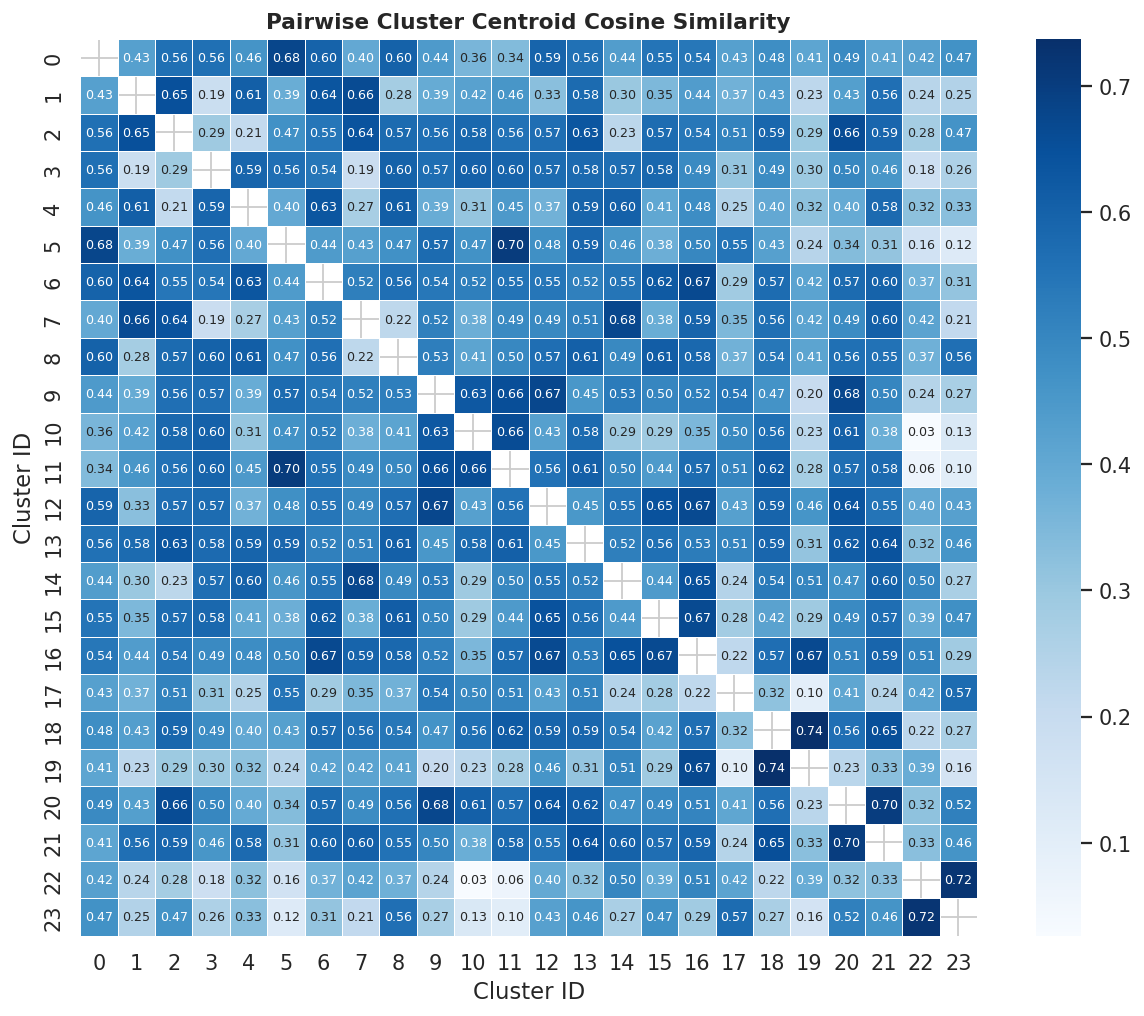

Saved: cluster_overlap.png
Most similar cluster pair: 18 ↔ 19  (cosine=0.737)


In [13]:

centroids = []
cid_list  = []
for cid in cluster_ids:
    idx = df.index[df['cluster_id'] == cid]
    centroids.append(embeddings[idx].mean(axis=0))
    cid_list.append(str(cid))

centroids = np.vstack(centroids)
sim_matrix = cosine_similarity(centroids)
sim_df     = pd.DataFrame(sim_matrix, index=cid_list, columns=cid_list)

fig, ax = plt.subplots(figsize=(10, 8))
mask_diag = np.eye(len(cid_list), dtype=bool)
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='Blues',
             mask=mask_diag, linewidths=0.3, ax=ax, square=True,
             annot_kws={'size': 7})
ax.set_title('Pairwise Cluster Centroid Cosine Similarity', fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Cluster ID')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_overlap.png', dpi=130)
plt.show()
print('Saved: cluster_overlap.png')

np.fill_diagonal(sim_matrix, 0)
max_i, max_j = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
print(f'Most similar cluster pair: {cid_list[max_i]} ↔ {cid_list[max_j]}  (cosine={sim_matrix[max_i, max_j]:.3f})')


## 8. Hyperparameter sensitivity sweep

In [14]:

metrics_file = RESULTS_DIR / 'chunk_evaluation_metrics.csv'
if not metrics_file.exists():
    print('[SKIP] chunk_evaluation_metrics.csv not found — run chunk_clustering.py first')
else:
    sweep_df = pd.read_csv(metrics_file)
    print('Chunk pipeline clustering metrics:')
    display_cols = [c for c in ['run_tag','n_clusters','noise_pct','sil_cos_all',
                                 'sil_umap_all','dbcv','DB','CH'] if c in sweep_df.columns]
    print(sweep_df[display_cols].to_string(index=False))

    if 'n_clusters' in sweep_df.columns and len(sweep_df) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        for ax, (ycol, ylabel) in zip(axes, [
            ('n_clusters',  'k (clusters)'),
            ('noise_pct',   'Noise %'),
            ('sil_cos_all', 'Silhouette cosine'),
        ]):
            if ycol not in sweep_df.columns: continue
            axes[list(axes).index(ax)].plot(range(len(sweep_df)), sweep_df[ycol], 'o-', color='steelblue')
            ax.set_xlabel('Run'); ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel} across runs', fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'chunk_sweep_plot.png', dpi=130, bbox_inches='tight')
        plt.show()

Chunk pipeline clustering metrics:
          run_tag  n_clusters  noise_pct  sil_cos_all  sil_umap_all   dbcv
nc10_mcs2000_ms20          24      11.99       0.8044         0.836 0.5467


In [15]:
print('CLUSTER DEEP DIVE — SUMMARY')
coh = td.get('coh_df')
stb = td.get('stab_df')
print(f'\n{lbl}')
print(f'  Total chunks     : {len(df):,}')
print(f'  HDBSCAN clusters : k={df[df["cluster_id"]>=0]["cluster_id"].nunique()}')
print(f'  Noise (-1)       : {(df["cluster_id"] < 0).sum()} ({(df["cluster_id"] < 0).mean()*100:.1f}%)')
if coh is not None:
    print(f'  Mean intra-cluster cosine : {coh["avg_cosine"].mean():.4f} ± {coh["avg_cosine"].std():.4f}')
if stb is not None:
    mean_ari = stb["ari"].mean()
    print(f'  Stability ARI ({len(stb)} seeds, {_CAP:,}-row subsample): {mean_ari:.3f} ± {stb["ari"].std():.3f}')
    print(f'  Note: ARI uses a {_CAP:,}-row subsample — HDBSCAN recovers fewer clusters than the full 24.')
print('\nAll artifacts saved to data/')

CLUSTER DEEP DIVE — SUMMARY

Chunk pipeline — paraphrase-multilingual-MiniLM-L12-v2 (contrastive fine-tuned, 384-d)
  Total chunks     : 169,709
  HDBSCAN clusters : k=24
  Noise (-1)       : 20346 (12.0%)
  Mean intra-cluster cosine : 0.9542 ± 0.0212
  Stability ARI (2 seeds, 12,000-row subsample): 0.112 ± 0.081
  Note: ARI uses a 12,000-row subsample — HDBSCAN recovers fewer clusters than the full 24.

All artifacts saved to data/
